# CaCO3 precipitation with CO2(g)
- solves saturated concentration of Ca2+ under fixed pCO2
- considers activity coefficients (Davies model)

In [1]:
import sys
sys.path.append('../')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Load data

In [3]:
import eq_solver
import summarize
import yaml

In [4]:
path = 'Ca-CO3.yaml'
s = eq_solver.EqSystem.from_yaml(path, temperature=298.15)
# contents of .yaml file
with open(path, encoding='utf-8') as fp:
    config = yaml.safe_load(fp)
display(config)

{'activity_model': 'davies',
 'temperature': 298.15,
 'components': [{'name': 'proton',
   'base': 'H+',
   'constraint': 'charge',
   'charge': 1},
  {'name': 'carbonate', 'base': 'CO2(g)', 'constraint': 'direct', 'charge': 0},
  {'name': 'calcium', 'base': 'Ca2+', 'constraint': 'total', 'charge': 2}],
 'species': [{'name': 'H+', 'phase': 'liquid'},
  {'name': 'OH-', 'phase': 'liquid'},
  {'name': 'CO2(g)', 'phase': 'gas'},
  {'name': 'CO2aq', 'phase': 'liquid'},
  {'name': 'HCO3-', 'phase': 'liquid'},
  {'name': 'CO3^2-', 'phase': 'liquid'},
  {'name': 'Ca2+', 'phase': 'liquid'},
  {'name': '[CaCO3]aq', 'phase': 'liquid'},
  {'name': '[CaHCO3]aq', 'phase': 'liquid'},
  {'name': 'CaCO3(s)', 'phase': 'solid'},
  {'name': '[CaOH]+aq', 'phase': 'liquid'},
  {'name': 'Ca(OH)2(s)', 'phase': 'solid'}],
 'equilibria': [{'name': 'water autoionization',
   'logK': -14.0,
   'DH': 55.8,
   'composition': {'H+': 1, 'OH-': 1}},
  {'name': 'CO2 dissolution',
   'logK': -1.47,
   'DH': -19.7,
   'c

In [5]:
print('---------- Equilibrium table generated from yaml ----------')
_df = pd.DataFrame(s.composition_matrix, index=s.spc_names, columns=s.cpt_base)
_df['logK'] = s.spc_logK
display(_df)

---------- Equilibrium table generated from yaml ----------


,H+,CO2(g),Ca2+,logK
H+,1.0,-0.0,-0.0,0.00
OH-,-1.0,0.0,0.0,-14.00
CO2(g),0.0,1.0,-0.0,-0.00
CO2aq,-0.0,1.0,-0.0,-1.47
HCO3-,-1.0,1.0,-0.0,-7.77
CO3^2-,-2.0,1.0,-0.0,-18.10
Ca2+,0.0,-0.0,1.0,0.00
[CaCO3]aq,-2.0,1.0,1.0,-14.90
[CaHCO3]aq,-1.0,1.0,1.0,-6.50
CaCO3(s),-2.0,1.0,1.0,-9.62


In [6]:
print('-'*80)
print('arguments of solver function: ')
for name in s.get_arg_names():
    print('  - ' + name)
print('-'*80)
print('return values of solver function:')
for name in s.get_return_names():
    print('  - ' + name)

--------------------------------------------------------------------------------
arguments of solver function: 
  - Log a(H+)
  - Log a(Ca2+)
  - mole(CaCO3(s))
  - mole(Ca(OH)2(s))
  - I
--------------------------------------------------------------------------------
return values of solver function:
  - calcium mole conservation
  - solid-liquid eq. of CaCO3(s)
  - solid-liquid eq. of Ca(OH)2(s)
  - charge conservation
  - self-consistency of I


# Problem 1: saturated concentration of Ca(OH)2

In [7]:
cond = eq_solver.Conditions.from_dict(
    system=s,
    concentrations={'carbonate': 0.0, 'calcium': 0.1}
)
l = eq_solver.solve_for_conditions(s, [cond])
print(f'- total Ca2+ = {l[0].total_conc_in_liquid("calcium"):.3f} mol/L')
print(f'-         pH = {l[0].pH():.2f}')

- total Ca2+ = 0.021 mol/L
-         pH = 12.48


In [8]:
# Details
print('- concentration of each species: ')
display(pd.Series(l[0].spc_c, index=s.spc_names))
print('- solver results: ')
display(l[0].sol)

- concentration of each species: 


H+            4.050646e-13
OH-           3.680742e-02
CO2(g)        0.000000e+00
CO2aq         0.000000e+00
HCO3-         0.000000e+00
CO3^2-        0.000000e+00
Ca2+          1.579459e-02
[CaCO3]aq     0.000000e+00
[CaHCO3]aq    0.000000e+00
CaCO3(s)      6.535368e-07
[CaOH]+aq     5.218243e-03
Ca(OH)2(s)    7.898652e-02
dtype: float64

- solver results: 


     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [ 0.000e+00 -6.535e-07  0.000e+00  0.000e+00  0.000e+00]
           x: [-1.248e+01 -2.148e+00  6.535e-07  7.899e-02  5.260e-02]
        cost: 2.1355558414187737e-13
         jac: [[ 5.218e-02 -2.101e-01 ... -4.343e+00 -3.968e-01]
               [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
               ...
               [ 8.582e-01  1.000e+00 ...  0.000e+00  1.494e+00]
               [-3.995e-01  6.501e-01 ...  0.000e+00 -6.631e+00]]
        grad: [ 0.000e+00  0.000e+00  6.535e-07  0.000e+00  0.000e+00]
  optimality: 4.271107856666892e-13
 active_mask: [0 0 0 0 0]
        nfev: 29
        njev: 27

# Problem 1.5: What if we don't consider activity coefficients?

In [9]:
from copy import deepcopy
config2 = deepcopy(config)
config2['activity_model'] = 'none'
s2 = eq_solver.EqSystem.from_config(config2)

cond = eq_solver.Conditions.from_dict(
    system=s2,
    concentrations={'carbonate': 0.0, 'calcium': 0.1}
)
l = eq_solver.solve_for_conditions(s2, [cond])

print(f'- total Ca2+ = {l[0].total_conc_in_liquid("calcium"):.3f} mol/L')
print(f'-         pH = {l[0].pH():.2f}')

- total Ca2+ = 0.015 mol/L
-         pH = 12.40


# Problem 2: Ca2+ solution, under given pCO2

In [10]:
pco2 = np.logspace(-6, 1, 100)
ca = 0.02  # total mole of Ca2+
cond_list = [eq_solver.Conditions.from_dict(s, {'carbonate': p, 'calcium': ca}) for p in pco2]

In [11]:
l = eq_solver.solve_for_conditions(s, cond_list)
df = summarize.get_summary(l)
df  # negative total proton(aq) means H+ consumption through reactions.

,cond.direct.carbonate,cond.total.calcium,sol.rmse,sol.retries,sol.nfev,pH,total proton(aq),total carbonate(aq),total calcium(aq)
0,0.000001,0.02,4.109406e-08,0,25,9.792259,-0.000249,0.000147,0.000124
1,0.000001,0.02,1.669455e-12,0,18,9.754630,-0.000251,0.000155,0.000126
2,0.000001,0.02,7.078996e-12,0,7,9.716416,-0.000255,0.000163,0.000127
3,0.000002,0.02,1.750088e-12,0,9,9.677630,-0.000259,0.000173,0.000129
4,0.000002,0.02,1.728638e-12,0,9,9.638289,-0.000263,0.000182,0.000132
...,...,...,...,...,...,...,...,...,...
95,5.214008,0.02,3.902877e-09,0,18,5.515994,-0.040000,0.216671,0.020000
96,6.135907,0.02,2.953075e-15,0,8,5.445312,-0.040000,0.247911,0.020000
97,7.220809,0.02,3.071997e-11,0,5,5.374628,-0.040000,0.284674,0.020000
98,8.497534,0.02,3.072100e-11,0,5,5.303943,-0.040000,0.327936,0.020000


In [12]:
# save data as csv
df_all = summarize.get_all(l)
df_all.to_csv('CaCO3-under-pCO2.csv', encoding='utf-8')

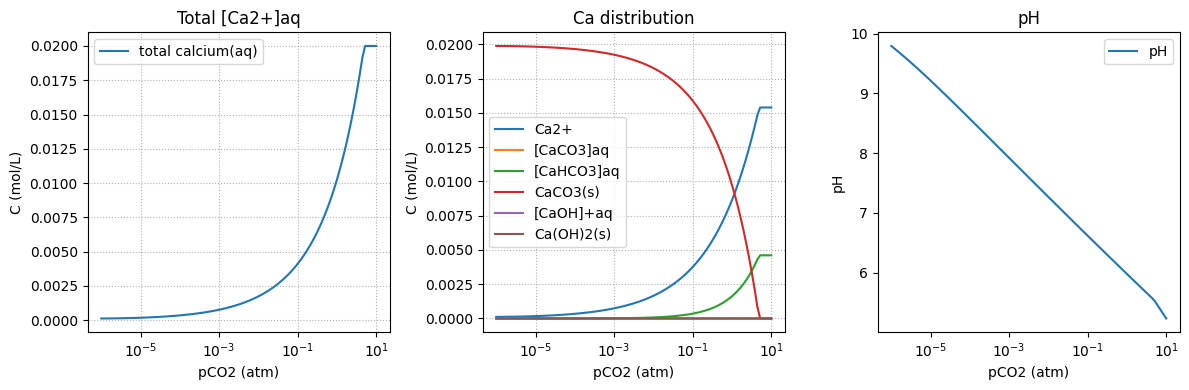

In [13]:
# Total solubility of Ca2+, Ca2+ distribution, pH
fig, axes = plt.subplots(ncols=3)
fig.set_size_inches(12, 4)
plt.sca(axes[0])
df.plot(x='cond.direct.carbonate', y='total calcium(aq)', title='Total [Ca2+]aq', ax=axes[0])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[1])
df_Ca = summarize.get_distribution(l, 'calcium')
df_Ca.plot(x='cond.direct.carbonate', title='Ca distribution',
           y=[c for c in df_Ca.columns if 'Ca' in c], 
           ax=axes[1])
plt.xscale('log')
plt.ylabel('C (mol/L)')
plt.xlabel('pCO2 (atm)')
plt.grid(True, ls=':')

plt.sca(axes[2])
df.plot(x='cond.direct.carbonate', y='pH', title='pH', ax=axes[2])
plt.xscale('log')
plt.ylabel('pH')
plt.xlabel('pCO2 (atm)')
fig.set_tight_layout(True)

# Problem 3: temperature dependence of solubility of Ca(OH)2

In [14]:
t_list = np.linspace(0, 100, 21)
systems = [eq_solver.EqSystem.from_yaml(path, temperature=273.15+t) for t in t_list]
conds = [eq_solver.Conditions.from_dict(s, {'calcium': 0.1, 'carbonate': 0.0}) for s in systems]
solubility = []

for s, c in zip(systems, conds):
    f = s.make_f(c)
    r = f.solve()
    cCa = r.total_conc_in_liquid('calcium')
    solubility.append(cCa * 74.093 / 10) # in g/100mL

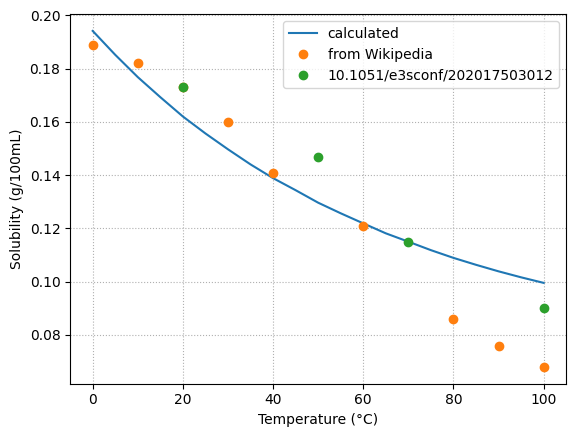

In [15]:
plt.figure()
plt.plot(t_list, solubility, label='calculated')
plt.plot([0, 10, 20, 30, 40, 60, 80, 90, 100],
         [0.189, 0.182, 0.173, 0.16, 0.141, 0.121, 0.086, 0.076, 0.068],
         'o',
         label='from Wikipedia')
plt.plot([20, 50, 70, 100],
         [0.173, 0.147, 0.115, 0.09],
         'o',
         label='10.1051/e3sconf/202017503012')
plt.xlabel('Temperature (°C)')
plt.ylabel('Solubility (g/100mL)')
plt.grid(True, ls=':')
plt.legend()